# EEG_00_labels_and_tasks

Questo notebook crea **etichette alternative** per le 110 parole del dataset.
L'idea è non fermarsi a uno schema solo, ma confrontare più approcci e poi scegliere quello più sensato per il training EEG.

## Perché non basta il clustering manuale

Sì, esistono approcci più rigorosi. Il problema del clustering manuale è che introduce **bias del ricercatore**: sei tu a decidere le categorie, non i dati.

## Approcci che mettiamo nel file

### 1) Ward su embeddings semantici
È già un approccio automatico. Però se la silhouette preferisce `k=2`, vuol dire che forzare 4 o 5 cluster potrebbe non riflettere una vera struttura naturale nello spazio semantico.

### 2) Norme psicolinguistiche
Approccio standard in neuroscienza cognitiva. L'idea è usare rating empirici come:
- concreteness / abstractness
- imageability
- valence / arousal
- eventuali norme sensorimotorie

Qui il clustering non nasce da categorie inventate a mano, ma da misure raccolte sperimentalmente. Nel notebook lasciamo una sezione pronta, così se aggiungi un file `.csv` con queste norme puoi generare cluster in modo riproducibile.

### 3) EEG-driven clustering
È l'approccio più interessante per la tesi BCI.
Invece di partire dal significato linguistico, parti dal segnale EEG:
- fai il prototipo medio per ogni parola
- fai clustering nello spazio EEG
- vedi se emergono gruppi interpretabili

In questo modo **le categorie emergono dai dati cerebrali**.

### 4) Manuale, ma solo come baseline
Teniamo anche gli schemi manuali POS e Semantico-BCI.
Non perché siano i più rigorosi, ma perché sono interpretabili e utili come confronto.

## Strategia finale
Nel notebook:
1. generiamo più mapping
2. li valutiamo con metriche interne
3. confrontiamo interpretabilità e utilità pratica
4. poi decidiamo quale portare nel training principale

Output in `data/interim/`:
- `idx2label.json`
- `word2cluster_4.json` / `labelid2cluster_4.json`
- `word2cluster_5.json` / `labelid2cluster_5.json`
- `word2cluster_pos4.json` / `labelid2cluster_pos4.json`
- `word2cluster_sem5.json` / `labelid2cluster_sem5.json`
- opzionali: `word2cluster_psycho_*.json`, `word2cluster_eeg_*.json`

Data: 2026-03-12


In [1]:
from pathlib import Path
import os, json, gc, warnings
import numpy as np
import pandas as pd
from collections import defaultdict

# evita warning/tokenizers fork
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore", category=FutureWarning)

project_root = Path("/Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech")
interim_dir = project_root / "data" / "interim"
interim_dir.mkdir(parents=True, exist_ok=True)

label2idx_path = interim_dir / "label2idx.json"
assert label2idx_path.exists(), f"Missing {label2idx_path}"

with open(label2idx_path, "r", encoding="utf-8") as f:
    label2idx = json.load(f)

label2idx = {str(k): int(v) for k, v in label2idx.items()}
idx2label = {int(v): str(k) for k, v in label2idx.items()}

# lista parole in ordine di label_id
true_labels = [idx2label[i] for i in sorted(idx2label.keys())]

print("num labels:", len(true_labels))
print("first 10:", true_labels[:10])

# salva idx2label comodo
idx2label_path = interim_dir / "idx2label.json"
with open(idx2label_path, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in idx2label.items()}, f, ensure_ascii=False, indent=2)
print("saved:", idx2label_path)

# config anti-crash
FAST_MODE = True
RANDOM_STATE = 42
MAX_K = 8 if FAST_MODE else 10
ANNOTATE_EVERY = 10 if FAST_MODE else 6


num labels: 110
first 10: ['accendere', 'acqua', 'adesso', 'aiuto', 'amore', 'anche', 'andare', 'anno', 'ansia', 'aprire']
saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/idx2label.json


## Install (una volta sola nell’ambiente)
Se ti mancano librerie, scommenta e runna.


In [2]:
# !pip install -q sentence-transformers scipy scikit-learn


In [3]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# NB: SentenceTransformer NON viene importato qui per evitare di caricare
# PyTorch (molto pesante in RAM) quando gli embedding sono già in cache.
# Viene importato on-demand nella cella successiva solo se necessario.


## 1) Embeddings semantici


In [4]:
import sys

MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
# alternativa più specifica per italiano, da provare a parte:
# MODEL_NAME = "dbmdz/bert-base-italian-cased"

# --- Cache degli embedding su disco per evitare di caricare PyTorch/SentenceTransformer ---
# Su macchine con poca RAM disponibile (~3-4 GB su 16 GB), caricare PyTorch
# consuma troppa memoria e causa crash del kernel nelle celle successive.
emb_cache_path = interim_dir / f"emb_cache_{MODEL_NAME.replace('/', '_')}.npy"

if emb_cache_path.exists():
    print(f"Cache trovata: {emb_cache_path}")
    emb = np.load(emb_cache_path)
    print("Embedding caricati da cache (PyTorch NON è stato caricato in memoria).")
else:
    print("Cache non trovata. Caricamento modello SentenceTransformer...")
    print("Embedding model:", MODEL_NAME)
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(MODEL_NAME, device="cpu")

    emb = model.encode(
        true_labels,
        normalize_embeddings=True,
        show_progress_bar=False,
        batch_size=16,
        convert_to_numpy=True,
    )
    emb = np.asarray(emb, dtype=np.float32)

    # salva cache su disco
    np.save(emb_cache_path, emb)
    print(f"Cache salvata: {emb_cache_path}")

    # --- Pulizia aggressiva di PyTorch dalla memoria ---
    # 'del model' da solo non basta: PyTorch tiene allocata molta RAM
    # anche dopo il delete. Rimuoviamo i moduli torch da sys.modules.
    del model
    torch_modules = [k for k in sys.modules if k.startswith(('torch', 'sentence_transformers'))]
    for k in torch_modules:
        del sys.modules[k]
    gc.collect()
    print("Memoria PyTorch/SentenceTransformer liberata.")

print("emb shape:", emb.shape)
print("emb dtype:", emb.dtype)


Cache trovata: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/emb_cache_paraphrase-multilingual-MiniLM-L12-v2.npy
Embedding caricati da cache (PyTorch NON è stato caricato in memoria).
emb shape: (110, 384)
emb dtype: float32


## 2) Clustering gerarchico + dendrogram (Ward)


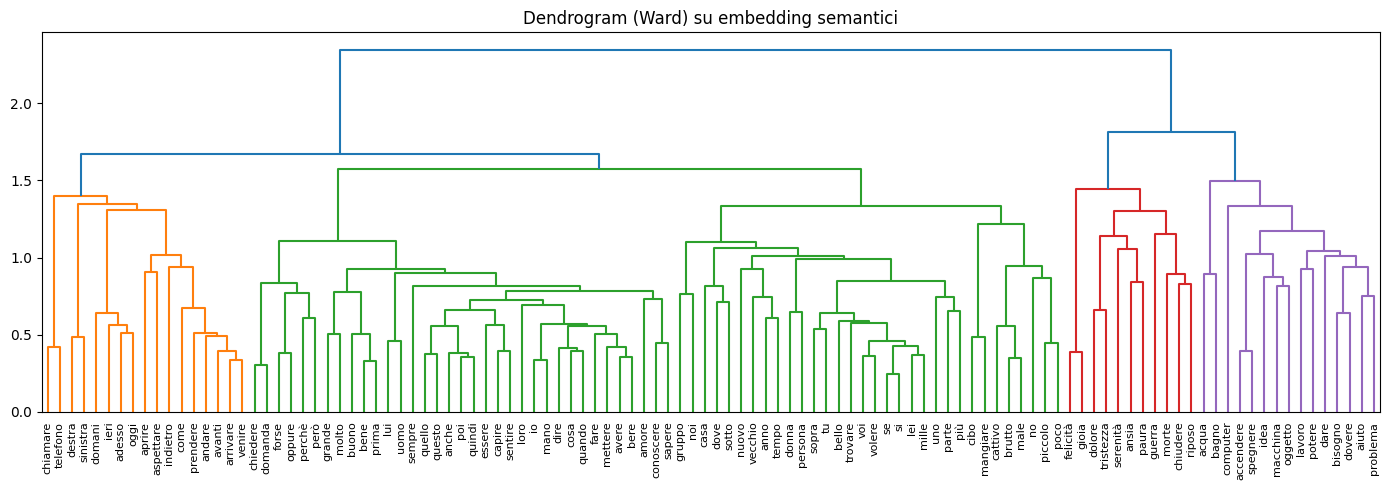

In [5]:
Z = linkage(emb, method="ward")

plt.figure(figsize=(14, 5))
dendrogram(Z, labels=true_labels, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrogram (Ward) su embedding semantici")
plt.tight_layout()
plt.show()
plt.close()


## 3) Ward automatico a 4 cluster

Qui teniamo il clustering gerarchico automatico come baseline semantica.


In [6]:
cluster_ids_4 = fcluster(Z, t=4, criterion="maxclust")  # 1..4
cluster_ids_4 = cluster_ids_4 - 1                       # 0..3

cluster2words_4 = defaultdict(list)
for w, c in zip(true_labels, cluster_ids_4):
    cluster2words_4[int(c)].append(w)

print("=== CLUSTER A 4 CLASSI ===")
for c in sorted(cluster2words_4.keys()):
    print(f"\nCLUSTER {c}:")
    print(", ".join(cluster2words_4[c]))

word2cluster_4 = {w: int(c) for w, c in zip(true_labels, cluster_ids_4)}
out_word2c4 = interim_dir / "word2cluster_4.json"
with open(out_word2c4, "w", encoding="utf-8") as f:
    json.dump(word2cluster_4, f, ensure_ascii=False, indent=2)
print(f"\nSaved semantic cluster mapping to {out_word2c4}")


=== CLUSTER A 4 CLASSI ===

CLUSTER 0:
adesso, andare, aprire, arrivare, aspettare, avanti, chiamare, come, destra, domani, ieri, indietro, oggi, prendere, sinistra, telefono, venire

CLUSTER 1:
amore, anche, anno, avere, bello, bene, bere, brutto, buono, capire, casa, cattivo, chiedere, cibo, conoscere, cosa, dire, domanda, donna, dove, essere, fare, forse, grande, gruppo, io, lei, loro, lui, male, mangiare, mano, mettere, mille, molto, no, noi, nuovo, oppure, parte, perchè, persona, però, piccolo, più, poco, poi, prima, quando, quello, questo, quindi, sapere, se, sempre, sentire, si, sopra, sotto, tempo, trovare, tu, uno, uomo, vecchio, voi, volere

CLUSTER 2:
ansia, chiudere, dolore, felicità, gioia, guerra, morte, paura, riposo, serenità, tristezza

CLUSTER 3:
accendere, acqua, aiuto, bagno, bisogno, computer, dare, dovere, idea, lavoro, macchina, oggetto, potere, problema, spegnere

Saved semantic cluster mapping to /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-s

## 4) 5 cluster: split SOLO del cluster più grande in 2 sottocluster (k=2)


In [7]:
# trova cluster più grande
sizes = {c: len(ws) for c, ws in cluster2words_4.items()}
big_c = max(sizes, key=sizes.get)
print("largest cluster (from 4):", big_c, "size:", sizes[big_c])

idx_big = [i for i, c in enumerate(cluster_ids_4) if int(c) == int(big_c)]
emb_big = emb[idx_big]

km_sub = KMeans(n_clusters=2, random_state=42, n_init=10)
sub_ids = km_sub.fit_predict(emb_big)  # 0/1

new_cluster_ids = np.array(cluster_ids_4, dtype=int)  # start from 0..3
new_id = 4

for j, i_word in enumerate(idx_big):
    if int(sub_ids[j]) == 0:
        new_cluster_ids[i_word] = int(big_c)
    else:
        new_cluster_ids[i_word] = new_id

# ricompatta per avere 0..4 sempre
uniq = sorted(np.unique(new_cluster_ids).tolist())
remap = {old: new for new, old in enumerate(uniq)}
cluster_ids_5 = np.array([remap[int(c)] for c in new_cluster_ids], dtype=int)

cluster2words_5 = defaultdict(list)
for w, c in zip(true_labels, cluster_ids_5):
    cluster2words_5[int(c)].append(w)

print("\n=== CLUSTER FINALI A 5 CLASSI ===")
for c in sorted(cluster2words_5.keys()):
    print(f"\nCLUSTER {c}:")
    print(", ".join(cluster2words_5[c]))

word2cluster_5 = {w: int(c) for w, c in zip(true_labels, cluster_ids_5)}
out_word2c5 = interim_dir / "word2cluster_5.json"
with open(out_word2c5, "w", encoding="utf-8") as f:
    json.dump(word2cluster_5, f, ensure_ascii=False, indent=2)
print(f"\nSaved semantic cluster mapping to {out_word2c5}")


largest cluster (from 4): 1 size: 67

=== CLUSTER FINALI A 5 CLASSI ===

CLUSTER 0:
adesso, andare, aprire, arrivare, aspettare, avanti, chiamare, come, destra, domani, ieri, indietro, oggi, prendere, sinistra, telefono, venire

CLUSTER 1:
anno, bello, brutto, casa, cattivo, cibo, donna, dove, fare, grande, gruppo, lei, male, mangiare, mille, no, nuovo, parte, persona, piccolo, più, poco, se, sopra, sotto, tempo, trovare, uno, uomo, vecchio, voi

CLUSTER 2:
ansia, chiudere, dolore, felicità, gioia, guerra, morte, paura, riposo, serenità, tristezza

CLUSTER 3:
accendere, acqua, aiuto, bagno, bisogno, computer, dare, dovere, idea, lavoro, macchina, oggetto, potere, problema, spegnere

CLUSTER 4:
amore, anche, avere, bene, bere, buono, capire, chiedere, conoscere, cosa, dire, domanda, essere, forse, io, loro, lui, mano, mettere, molto, noi, oppure, perchè, però, poi, prima, quando, quello, questo, quindi, sapere, sempre, sentire, si, tu, volere

Saved semantic cluster mapping to /Users/da

## 5) label_id -> cluster_id (per training)


In [8]:
labelid2cluster_4 = {int(label2idx[w]): int(word2cluster_4[w]) for w in true_labels}
labelid2cluster_5 = {int(label2idx[w]): int(word2cluster_5[w]) for w in true_labels}

out_l2c4 = interim_dir / "labelid2cluster_4.json"
out_l2c5 = interim_dir / "labelid2cluster_5.json"

with open(out_l2c4, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in labelid2cluster_4.items()}, f, ensure_ascii=False, indent=2)
with open(out_l2c5, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in labelid2cluster_5.items()}, f, ensure_ascii=False, indent=2)

print("saved:", out_l2c4)
print("saved:", out_l2c5)

print("\nEsempio mapping (prime 10 parole):")
for w in true_labels[:10]:
    print(w, "->", word2cluster_5[w])


saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/labelid2cluster_4.json
saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/labelid2cluster_5.json

Esempio mapping (prime 10 parole):
accendere -> 3
acqua -> 3
adesso -> 0
aiuto -> 3
amore -> 4
anche -> 4
andare -> 0
anno -> 1
ansia -> 2
aprire -> 0


## 6) Helper: rimappa y (label_id) in cluster_id


In [9]:
def remap_y_to_clusters(y, labelid2cluster):
    y = np.asarray(y, dtype=int)
    return np.array([labelid2cluster[int(v)] for v in y], dtype=int)

# esempio:
# with open(interim_dir/'labelid2cluster_5.json','r') as f: m = {int(k):int(v) for k,v in json.load(f).items()}
# y_cluster5 = remap_y_to_clusters(y_epochs, m)


---

## 7) Scelta di k e metriche interne

Questa parte era una delle cause del crash:
- `n_init=30` dentro il loop
- più plot nello stesso blocco
- memoria non liberata

Qui facciamo una versione più leggera.


,k,silhouette,davies_bouldin,inertia
0,2,0.109936,3.480312,36.693512
1,3,0.091931,3.197750,34.941605
2,4,0.047877,2.912969,33.523884
3,5,0.056112,2.579547,32.329880
4,6,0.052276,2.443230,31.445950
5,7,0.062689,2.663009,30.639011
6,8,0.096583,2.227733,29.781384


k ottimale per silhouette: 2


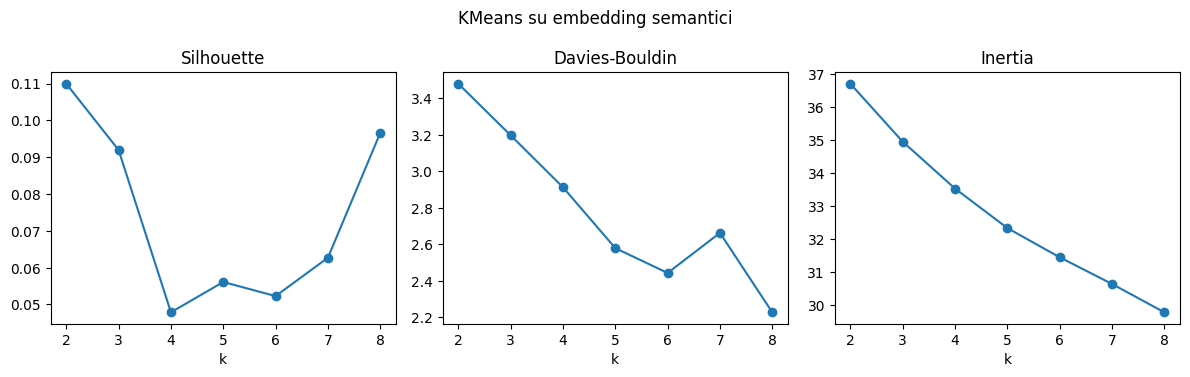

In [10]:
k_range = list(range(2, MAX_K + 1))
metrics = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(emb)
    metrics.append({
        "k": k,
        "silhouette": float(silhouette_score(emb, labels_k)),
        "davies_bouldin": float(davies_bouldin_score(emb, labels_k)),
        "inertia": float(km.inertia_),
    })

df_m = pd.DataFrame(metrics)
display(df_m)

best_k = int(df_m.loc[df_m["silhouette"].idxmax(), "k"])
print(f"k ottimale per silhouette: {best_k}")

fig = plt.figure(figsize=(12, 3.8))
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)

ax1.plot(df_m["k"], df_m["silhouette"], marker="o")
ax1.set_title("Silhouette")
ax1.set_xlabel("k")

ax2.plot(df_m["k"], df_m["davies_bouldin"], marker="o")
ax2.set_title("Davies-Bouldin")
ax2.set_xlabel("k")

ax3.plot(df_m["k"], df_m["inertia"], marker="o")
ax3.set_title("Inertia")
ax3.set_xlabel("k")

plt.suptitle("KMeans su embedding semantici")
plt.tight_layout()
plt.show()
plt.close()


---

## 8) Schema POS — 4 classi grammaticali (manuale)

Classificazione basata sulla **parte del discorso** (Part-of-Speech) italiana.  
È lo schema più rigido linguisticamente: ogni parola appartiene a una sola categoria grammaticale.

| Classe | Descrizione | Esempi |
|--------|-------------|--------|
| **VERBI** | Verbi all'infinito presente | andare, fare, sentire |
| **SOSTANTIVI** | Sostantivi concreti e astratti | casa, dolore, idea |
| **MODIFICATORI** | Aggettivi e avverbi con contenuto lessicale | bello, sempre, piccolo |
| **GRAMMATICALI** | Pronomi, congiunzioni, particelle | io, perchè, oppure |

> Questa classificazione è **indipendente dagli embedding**: non usa affatto il modello SBERT.


In [11]:
# Schema POS: 4 classi grammaticali italiane
manual_pos = {
    "VERBI": [
        # tutti verbi all'infinito presente — azioni fisiche, cognitive, modali
        "accendere", "andare", "aprire", "arrivare", "aspettare", "avere",
        "bere", "capire", "chiamare", "chiedere", "chiudere", "conoscere",
        "dare", "dire", "dovere", "essere", "fare", "mangiare", "mettere",
        "potere", "prendere", "sapere", "sentire", "spegnere", "trovare",
        "venire", "volere"
    ],
    "SOSTANTIVI": [
        # nomi concreti e astratti — oggetti, luoghi, stati, concetti
        "acqua", "aiuto", "amore", "anno", "ansia", "bagno", "bisogno",
        "casa", "cibo", "computer", "dolore", "domanda", "donna", "felicità",
        "gioia", "gruppo", "guerra", "idea", "lavoro", "macchina", "mano",
        "mille", "morte", "oggetto", "paura", "parte", "persona", "problema",
        "riposo", "serenità", "telefono", "tempo", "tristezza", "uomo"
    ],
    "MODIFICATORI": [
        # aggettivi e avverbi con significato lessicale autonomo
        "adesso", "avanti", "bello", "bene", "brutto", "buono", "cattivo",
        "destra", "domani", "grande", "ieri", "indietro", "male", "molto",
        "nuovo", "oggi", "piccolo", "più", "poco", "poi", "prima",
        "sempre", "sinistra", "sopra", "sotto", "vecchio"
    ],
    "GRAMMATICALI": [
        # pronomi personali, congiunzioni, particelle, numerali, deittici
        "anche", "come", "cosa", "dove", "forse", "io", "lei", "loro",
        "lui", "no", "noi", "oppure", "perchè", "però", "quando",
        "quello", "questo", "quindi", "se", "si", "tu", "uno", "voi"
    ]
}

# --- validazione: ogni parola del dataset deve apparire esattamente una volta ---
all_assigned_pos = [w for ws in manual_pos.values() for w in ws]
missing_pos  = set(true_labels) - set(all_assigned_pos)
extra_pos    = set(all_assigned_pos) - set(true_labels)
dupl_pos     = {w for w in all_assigned_pos if all_assigned_pos.count(w) > 1}

print(f"Dataset: {len(true_labels)} parole | Assegnate: {len(all_assigned_pos)}")
print(f"Mancanti dal dataset: {missing_pos or '—'}")
print(f"Parole extra (non nel dataset): {extra_pos or '—'}")
print(f"Duplicati: {dupl_pos or '—'}")

print("\n=== SCHEMA POS — 4 CLASSI ===")
for cat, words in manual_pos.items():
    print(f"\n{cat} ({len(words)}):")
    print(", ".join(sorted(words)))


Dataset: 110 parole | Assegnate: 110
Mancanti dal dataset: —
Parole extra (non nel dataset): —
Duplicati: —

=== SCHEMA POS — 4 CLASSI ===

VERBI (27):
accendere, andare, aprire, arrivare, aspettare, avere, bere, capire, chiamare, chiedere, chiudere, conoscere, dare, dire, dovere, essere, fare, mangiare, mettere, potere, prendere, sapere, sentire, spegnere, trovare, venire, volere

SOSTANTIVI (34):
acqua, aiuto, amore, anno, ansia, bagno, bisogno, casa, cibo, computer, dolore, domanda, donna, felicità, gioia, gruppo, guerra, idea, lavoro, macchina, mano, mille, morte, oggetto, parte, paura, persona, problema, riposo, serenità, telefono, tempo, tristezza, uomo

MODIFICATORI (26):
adesso, avanti, bello, bene, brutto, buono, cattivo, destra, domani, grande, ieri, indietro, male, molto, nuovo, oggi, piccolo, più, poco, poi, prima, sempre, sinistra, sopra, sotto, vecchio

GRAMMATICALI (23):
anche, come, cosa, dove, forse, io, lei, loro, lui, no, noi, oppure, perchè, però, quando, quello, qu

In [12]:
# Costruzione mapping e salvataggio schema POS-4
cat_names_pos4 = list(manual_pos.keys())

word2cluster_pos4 = {}
for cat_id, (cat_name, words) in enumerate(manual_pos.items()):
    for w in words:
        if w in set(true_labels):
            word2cluster_pos4[w] = cat_id

# catch-all per eventuali parole non coperte dallo schema
for w in true_labels:
    if w not in word2cluster_pos4:
        print(f"ATTENZIONE: '{w}' non assegnata → assegnata a GRAMMATICALI (3)")
        word2cluster_pos4[w] = 3

labelid2cluster_pos4 = {int(label2idx[w]): int(word2cluster_pos4[w]) for w in true_labels}

out_pos4      = interim_dir / "word2cluster_pos4.json"
out_pos4_lid  = interim_dir / "labelid2cluster_pos4.json"
out_pos4_names = interim_dir / "cluster_names_pos4.json"

with open(out_pos4, "w", encoding="utf-8") as f:
    json.dump(word2cluster_pos4, f, ensure_ascii=False, indent=2)
with open(out_pos4_lid, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in labelid2cluster_pos4.items()}, f, ensure_ascii=False, indent=2)
with open(out_pos4_names, "w", encoding="utf-8") as f:
    json.dump({str(i): name for i, name in enumerate(cat_names_pos4)}, f, ensure_ascii=False, indent=2)

print(f"Saved: {out_pos4}")
print(f"Saved: {out_pos4_lid}")
print(f"Saved: {out_pos4_names}")
print("\nDistribuzione classi POS-4:")
for cat_id, cat_name in enumerate(cat_names_pos4):
    count = sum(1 for v in word2cluster_pos4.values() if v == cat_id)
    print(f"  {cat_id} — {cat_name:15s}: {count:3d} parole  {'█' * count}")


Saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/word2cluster_pos4.json
Saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/labelid2cluster_pos4.json
Saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/cluster_names_pos4.json

Distribuzione classi POS-4:
  0 — VERBI          :  27 parole  ███████████████████████████
  1 — SOSTANTIVI     :  34 parole  ██████████████████████████████████
  2 — MODIFICATORI   :  26 parole  ██████████████████████████
  3 — GRAMMATICALI   :  23 parole  ███████████████████████


---

## 9) Schema Semantico-BCI — 5 classi (manuale)

Classificazione basata su **categorie semantiche rilevanti per l'EEG e il BCI**.  
Ogni classe è associata a un substrato neurale diverso, il che motiva la scelta per il decoding.

| Classe | Substrato neurale atteso | Descrizione |
|--------|--------------------------|-------------|
| **AZIONI** | Corteccia motoria/premotoria (imagery motoria) | Tutti i verbi all'infinito |
| **EMOZIONI_VALENZA** | Sistema limbico, amigdala, corteccia orbito-frontale | Emozioni + aggettivi valutativi |
| **OGGETTI_PERSONE** | Corteccia temporale inferiore (riconoscimento oggetti) | Sostantivi concreti, fisici |
| **CONCETTI_ASTRATTI** | Corteccia prefrontale, temporale superiore | Sostantivi astratti, situazioni |
| **PAROLE_FUNZIONE** | Aree linguistiche (Broca/Wernicke), rete del default mode | Pronomi, congiunzioni, deittici, quantificatori |

> **Motivazione**: rispetto al Ward gerarchico, questa classificazione evita cluster incoerenti  
> (es. il vecchio CLUSTER 1 con 67 parole eterogenee) e permette interpretazioni neurologiche dirette.


In [13]:
# Schema Semantico-BCI: 5 classi neuroscientificamente motivate
manual_sem5 = {
    "AZIONI": [
        # tutti i verbi all'infinito (imagery motoria, action planning)
        "accendere", "andare", "aprire", "arrivare", "aspettare", "avere",
        "bere", "capire", "chiamare", "chiedere", "chiudere", "conoscere",
        "dare", "dire", "dovere", "essere", "fare", "mangiare", "mettere",
        "potere", "prendere", "sapere", "sentire", "spegnere", "trovare",
        "venire", "volere"
    ],
    "EMOZIONI_VALENZA": [
        # stati emotivi e aggettivi con valenza affettiva forte (sistema limbico)
        "amore", "ansia", "bello", "bene", "brutto", "buono", "cattivo",
        "dolore", "felicità", "gioia", "guerra", "male", "morte",
        "paura", "riposo", "serenità", "tristezza"
    ],
    "OGGETTI_PERSONE": [
        # referenti concreti fisicamente immaginabili: oggetti, luoghi, persone
        "acqua", "aiuto", "bagno", "casa", "cibo", "computer", "donna",
        "gruppo", "macchina", "mano", "oggetto", "persona", "telefono", "uomo"
    ],
    "CONCETTI_ASTRATTI": [
        # sostantivi astratti: concetti, situazioni, relazioni senza referente fisico
        "anno", "bisogno", "domanda", "idea", "lavoro", "mille",
        "parte", "problema", "tempo"
    ],
    "PAROLE_FUNZIONE": [
        # pronomi personali, congiunzioni, avverbi, deittici spaziali/temporali, quantificatori
        "adesso", "anche", "avanti", "come", "cosa", "destra", "domani",
        "dove", "forse", "grande", "ieri", "indietro", "io", "lei", "loro",
        "lui", "molto", "noi", "no", "nuovo", "oggi", "oppure", "perchè",
        "però", "piccolo", "più", "poco", "poi", "prima", "quando",
        "quello", "questo", "quindi", "se", "sempre", "sinistra", "si",
        "sopra", "sotto", "tu", "uno", "vecchio", "voi"
    ]
}

# --- validazione ---
all_assigned_sem = [w for ws in manual_sem5.values() for w in ws]
missing_sem  = set(true_labels) - set(all_assigned_sem)
extra_sem    = set(all_assigned_sem) - set(true_labels)
dupl_sem     = {w for w in all_assigned_sem if all_assigned_sem.count(w) > 1}

print(f"Dataset: {len(true_labels)} parole | Assegnate: {len(all_assigned_sem)}")
print(f"Mancanti: {missing_sem or '—'}")
print(f"Extra: {extra_sem or '—'}")
print(f"Duplicati: {dupl_sem or '—'}")

print("\n=== SCHEMA SEMANTICO-BCI — 5 CLASSI ===")
for cat, words in manual_sem5.items():
    print(f"\n{cat} ({len(words)}):")
    print(", ".join(sorted(words)))


Dataset: 110 parole | Assegnate: 110
Mancanti: —
Extra: —
Duplicati: —

=== SCHEMA SEMANTICO-BCI — 5 CLASSI ===

AZIONI (27):
accendere, andare, aprire, arrivare, aspettare, avere, bere, capire, chiamare, chiedere, chiudere, conoscere, dare, dire, dovere, essere, fare, mangiare, mettere, potere, prendere, sapere, sentire, spegnere, trovare, venire, volere

EMOZIONI_VALENZA (17):
amore, ansia, bello, bene, brutto, buono, cattivo, dolore, felicità, gioia, guerra, male, morte, paura, riposo, serenità, tristezza

OGGETTI_PERSONE (14):
acqua, aiuto, bagno, casa, cibo, computer, donna, gruppo, macchina, mano, oggetto, persona, telefono, uomo

CONCETTI_ASTRATTI (9):
anno, bisogno, domanda, idea, lavoro, mille, parte, problema, tempo

PAROLE_FUNZIONE (43):
adesso, anche, avanti, come, cosa, destra, domani, dove, forse, grande, ieri, indietro, io, lei, loro, lui, molto, no, noi, nuovo, oggi, oppure, perchè, però, piccolo, più, poco, poi, prima, quando, quello, questo, quindi, se, sempre, si, si

In [14]:
# Costruzione mapping e salvataggio schema Semantico-BCI 5
cat_names_sem5 = list(manual_sem5.keys())

word2cluster_sem5 = {}
for cat_id, (cat_name, words) in enumerate(manual_sem5.items()):
    for w in words:
        if w in set(true_labels):
            word2cluster_sem5[w] = cat_id

# catch-all
for w in true_labels:
    if w not in word2cluster_sem5:
        print(f"ATTENZIONE: '{w}' non assegnata → PAROLE_FUNZIONE (4)")
        word2cluster_sem5[w] = 4

labelid2cluster_sem5 = {int(label2idx[w]): int(word2cluster_sem5[w]) for w in true_labels}

out_sem5       = interim_dir / "word2cluster_sem5.json"
out_sem5_lid   = interim_dir / "labelid2cluster_sem5.json"
out_sem5_names = interim_dir / "cluster_names_sem5.json"

with open(out_sem5, "w", encoding="utf-8") as f:
    json.dump(word2cluster_sem5, f, ensure_ascii=False, indent=2)
with open(out_sem5_lid, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in labelid2cluster_sem5.items()}, f, ensure_ascii=False, indent=2)
with open(out_sem5_names, "w", encoding="utf-8") as f:
    json.dump({str(i): name for i, name in enumerate(cat_names_sem5)}, f, ensure_ascii=False, indent=2)

print(f"Saved: {out_sem5}")
print(f"Saved: {out_sem5_lid}")
print(f"Saved: {out_sem5_names}")
print("\nDistribuzione classi Semantico-BCI-5:")
for cat_id, cat_name in enumerate(cat_names_sem5):
    count = sum(1 for v in word2cluster_sem5.values() if v == cat_id)
    print(f"  {cat_id} — {cat_name:22s}: {count:3d} parole  {'█' * count}")


Saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/word2cluster_sem5.json
Saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/labelid2cluster_sem5.json
Saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/cluster_names_sem5.json

Distribuzione classi Semantico-BCI-5:
  0 — AZIONI                :  27 parole  ███████████████████████████
  1 — EMOZIONI_VALENZA      :  17 parole  █████████████████
  2 — OGGETTI_PERSONE       :  14 parole  ██████████████
  3 — CONCETTI_ASTRATTI     :   9 parole  █████████
  4 — PAROLE_FUNZIONE       :  43 parole  ███████████████████████████████████████████


---

## 10) Approccio psicolinguistico (opzionale ma rigoroso)

Questa sezione è pronta per quando avrai un file con norme tipo:
- `word`
- `concreteness`
- `imageability`
- `valence`
- `arousal`

Puoi aggiungere anche altre colonne continue.
Il clustering verrà fatto solo sulle feature numeriche disponibili.


In [15]:
psycho_csv = interim_dir / "psycholinguistic_norms.csv"

def _normalize_word(s):
    return str(s).strip().lower()

psycho_available = psycho_csv.exists()
word2cluster_psycho4 = None
word2cluster_psycho5 = None

if psycho_available:
    psycho = pd.read_csv(psycho_csv)
    assert "word" in psycho.columns, "Il csv deve avere una colonna 'word'"
    psycho["word"] = psycho["word"].map(_normalize_word)

    psycho = psycho.drop_duplicates(subset="word").copy()
    psycho = psycho[psycho["word"].isin([w.lower() for w in true_labels])].copy()

    num_cols = [c for c in psycho.columns if c != "word" and pd.api.types.is_numeric_dtype(psycho[c])]
    assert len(num_cols) >= 2, "Servono almeno 2 colonne numeriche per fare clustering"

    psycho = psycho.set_index("word").reindex([w.lower() for w in true_labels])
    missing_words = psycho.index[psycho[num_cols].isna().all(axis=1)].tolist()
    if missing_words:
        print("ATTENZIONE: parole senza norme complete:", missing_words)

    X_psy = psycho[num_cols].astype(np.float32)
    X_psy = X_psy.fillna(X_psy.mean())

    km4 = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
    km5 = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)

    labels_psy4 = km4.fit_predict(X_psy)
    labels_psy5 = km5.fit_predict(X_psy)

    word2cluster_psycho4 = {w: int(c) for w, c in zip(true_labels, labels_psy4)}
    word2cluster_psycho5 = {w: int(c) for w, c in zip(true_labels, labels_psy5)}

    with open(interim_dir / "word2cluster_psycho_4.json", "w", encoding="utf-8") as f:
        json.dump(word2cluster_psycho4, f, ensure_ascii=False, indent=2)
    with open(interim_dir / "word2cluster_psycho_5.json", "w", encoding="utf-8") as f:
        json.dump(word2cluster_psycho5, f, ensure_ascii=False, indent=2)

    with open(interim_dir / "labelid2cluster_psycho_4.json", "w", encoding="utf-8") as f:
        json.dump({str(label2idx[w]): int(word2cluster_psycho4[w]) for w in true_labels}, f, ensure_ascii=False, indent=2)
    with open(interim_dir / "labelid2cluster_psycho_5.json", "w", encoding="utf-8") as f:
        json.dump({str(label2idx[w]): int(word2cluster_psycho5[w]) for w in true_labels}, f, ensure_ascii=False, indent=2)

    print("Approccio psicolinguistico disponibile.")
    print("Feature usate:", num_cols)
    print("silhouette psycho-4:", round(float(silhouette_score(X_psy, labels_psy4)), 4))
    print("silhouette psycho-5:", round(float(silhouette_score(X_psy, labels_psy5)), 4))
else:
    print("Nessun file psycholinguistic_norms.csv trovato in data/interim/. Se vuoi, aggiungilo e riesegui questa cella.")


Nessun file psycholinguistic_norms.csv trovato in data/interim/. Se vuoi, aggiungilo e riesegui questa cella.


---

## 11) EEG-driven clustering

Questa è la parte più legata alla tesi.
Serve avere:
- `X_eeg`: array con shape `(n_trials, ...)`
- `y_eeg`: label id parola, shape `(n_trials,)`

Il codice sotto prova a usare variabili già in memoria.
Se non ci sono, puoi caricarle qui da file `.npy` o dal tuo dataloader.


In [16]:
def build_word_prototypes(X_eeg, y_eeg, n_words=None, reducer='mean'):
    X_eeg = np.asarray(X_eeg, dtype=np.float32)
    y_eeg = np.asarray(y_eeg, dtype=int).reshape(-1)
    assert len(X_eeg) == len(y_eeg), "X_eeg e y_eeg devono avere stessa lunghezza"

    if n_words is None:
        n_words = len(np.unique(y_eeg))

    flat = X_eeg.reshape(len(X_eeg), -1)
    prototypes = []
    valid_word_ids = []

    for word_id in range(n_words):
        mask = y_eeg == word_id
        if not np.any(mask):
            continue
        block = flat[mask]
        proto = block.mean(axis=0) if reducer == 'mean' else np.median(block, axis=0)
        prototypes.append(proto.astype(np.float32))
        valid_word_ids.append(word_id)

    prototypes = np.vstack(prototypes)
    return prototypes, valid_word_ids


def save_word_cluster_mapping(valid_word_ids, cluster_labels, suffix, n_cls=None):
    word2cluster = {}
    for wid, cid in zip(valid_word_ids, cluster_labels):
        word = idx2label[int(wid)]
        word2cluster[word] = int(cid)

    out_w = interim_dir / f"word2cluster_{suffix}.json"
    out_l = interim_dir / f"labelid2cluster_{suffix}.json"
    out_n = interim_dir / f"cluster_names_{suffix}.json"

    with open(out_w, "w", encoding="utf-8") as f:
        json.dump(word2cluster, f, ensure_ascii=False, indent=2)
    with open(out_l, "w", encoding="utf-8") as f:
        json.dump({str(label2idx[w]): int(c) for w, c in word2cluster.items()}, f, ensure_ascii=False, indent=2)

    # cluster_names serve a load_label_scheme() in utils.py
    if n_cls is None:
        n_cls = len(set(cluster_labels))
    with open(out_n, "w", encoding="utf-8") as f:
        json.dump({str(i): f"EEG_C{i}" for i in range(n_cls)}, f, ensure_ascii=False, indent=2)

    return word2cluster, out_w, out_l


# --- Caricamento dati EEG da eeg_epoch_tensors.pt ---
# Il file contiene features già estratte per ogni epoca:
#   X_epochs: lista di tensori (61 canali × 40 features) per ogni epoca
#   y_epochs: label IDs (0-109)
eeg_tensors_path = project_root / "data" / "processed" / "eeg_epoch_tensors.pt"

word2cluster_eeg4 = None
word2cluster_eeg5 = None
eeg_prototypes    = None   # tenuto in scope per silhouette in cella successiva

if eeg_tensors_path.exists():
    print(f"Caricamento dati EEG da: {eeg_tensors_path}")
    try:
        import torch
        eeg_data = torch.load(eeg_tensors_path, map_location="cpu", weights_only=False)

        # Converti in numpy: flatten ogni epoca (61, 40) -> (2440,)
        X_eeg = np.array([t.numpy().flatten() for t in eeg_data["X_epochs"]], dtype=np.float32)
        y_eeg = eeg_data["y_epochs"].numpy().astype(int)
        print(f"X_eeg shape: {X_eeg.shape}  |  y_eeg shape: {y_eeg.shape}")

        # --- Pulizia aggressiva di PyTorch dalla memoria ---
        del eeg_data
        torch_modules = [k for k in sys.modules if k.startswith('torch')]
        for k in torch_modules:
            del sys.modules[k]
        gc.collect()
        print("Memoria PyTorch liberata.")

        # Costruzione prototipi (media per parola nello spazio delle features EEG)
        eeg_prototypes, valid_word_ids = build_word_prototypes(
            X_eeg, y_eeg, n_words=len(true_labels)
        )
        print(f"EEG prototypes shape: {eeg_prototypes.shape}  ({eeg_prototypes.shape[0]} parole × {eeg_prototypes.shape[1]} feature)")

        del X_eeg, y_eeg
        gc.collect()

        # --- Clustering gerarchico Ward a 4 classi ---
        eeg_labels_4 = fcluster(linkage(eeg_prototypes, method="ward"), t=4, criterion="maxclust") - 1

        # --- KMeans a 5 classi ---
        km5 = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
        eeg_labels_5 = km5.fit_predict(eeg_prototypes)

        # Salva JSON + cluster_names (compatibile con load_label_scheme)
        word2cluster_eeg4, out_w4, out_l4 = save_word_cluster_mapping(
            valid_word_ids, eeg_labels_4, "eeg_4", n_cls=4
        )
        word2cluster_eeg5, out_w5, out_l5 = save_word_cluster_mapping(
            valid_word_ids, eeg_labels_5, "eeg_5", n_cls=5
        )

        print("Saved:", out_w4.name, out_l4.name)
        print("Saved:", out_w5.name, out_l5.name)
        print("silhouette EEG-4 (spazio EEG):", round(float(silhouette_score(eeg_prototypes, eeg_labels_4)), 4))
        print("silhouette EEG-5 (spazio EEG):", round(float(silhouette_score(eeg_prototypes, eeg_labels_5)), 4))

        # Stampa cluster EEG
        for suffix, labels in [("EEG-4", eeg_labels_4), ("EEG-5", eeg_labels_5)]:
            print(f"\n=== CLUSTER {suffix} ===")
            cls2words = defaultdict(list)
            for wid, cid in zip(valid_word_ids, labels):
                cls2words[cid].append(idx2label[wid])
            for c in sorted(cls2words):
                print(f"  C{c}: {', '.join(cls2words[c])}")

    except Exception as e:
        print(f"Errore nel caricamento/clustering EEG: {e}")
        import traceback; traceback.print_exc()
        word2cluster_eeg4 = None
        word2cluster_eeg5 = None
        eeg_prototypes    = None
else:
    print(f"File non trovato: {eeg_tensors_path}")
    print("Per generare i tensori, esegui prima EEG_02_tensors_and_graph.ipynb")


Caricamento dati EEG da: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/processed/eeg_epoch_tensors.pt


X_eeg shape: (38562, 2440)  |  y_eeg shape: (38562,)
Memoria PyTorch liberata.
EEG prototypes shape: (110, 2440)  (110 parole × 2440 feature)


Saved: word2cluster_eeg_4.json labelid2cluster_eeg_4.json
Saved: word2cluster_eeg_5.json labelid2cluster_eeg_5.json
silhouette EEG-4 (spazio EEG): 0.099
silhouette EEG-5 (spazio EEG): 0.0684

=== CLUSTER EEG-4 ===
  C0: acqua, andare, ansia, arrivare, aspettare, bello, buono, capire, casa, chiamare, chiedere, cibo, computer, conoscere, dire, domanda, dovere, essere, felicità, forse, gioia, guerra, indietro, macchina, male, mangiare, molto, morte, piccolo, più, poco, poi, potere, prima, quello, questo, riposo, sapere, se, sentire, sinistra, sotto, telefono, tristezza, uomo, voi
  C1: anche, bene, cattivo, cosa, dove, ieri, io, lavoro, no, paura, problema, quindi, tempo, trovare, vecchio
  C2: accendere, anno, aprire, avere, bagno, come, dolore, grande, lui, mettere, noi, oggetto, oggi, parte, persona, quando, serenità
  C3: adesso, aiuto, amore, avanti, bere, bisogno, brutto, chiudere, dare, destra, domani, donna, fare, gruppo, idea, lei, loro, mano, mille, nuovo, oppure, perchè, però, 

---

## 12) Visualizzazione comparata PCA 2D

Versione alleggerita per evitare crash.
Niente figure giganti, niente troppe annotazioni.


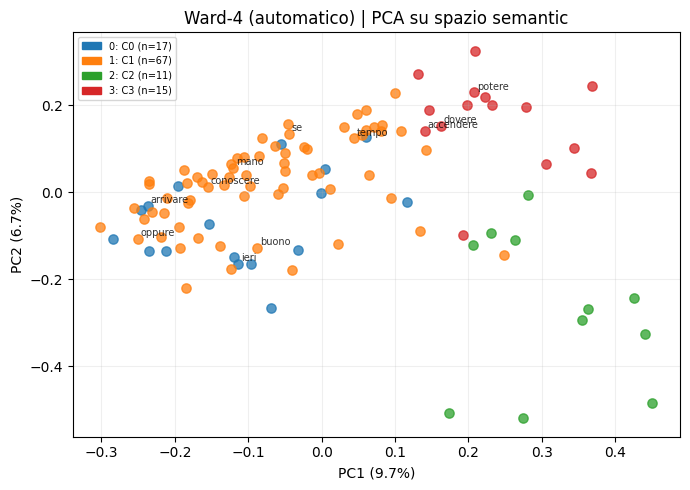

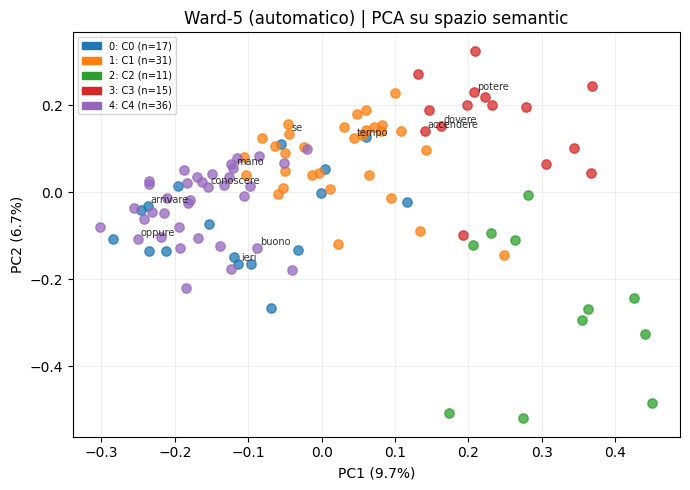

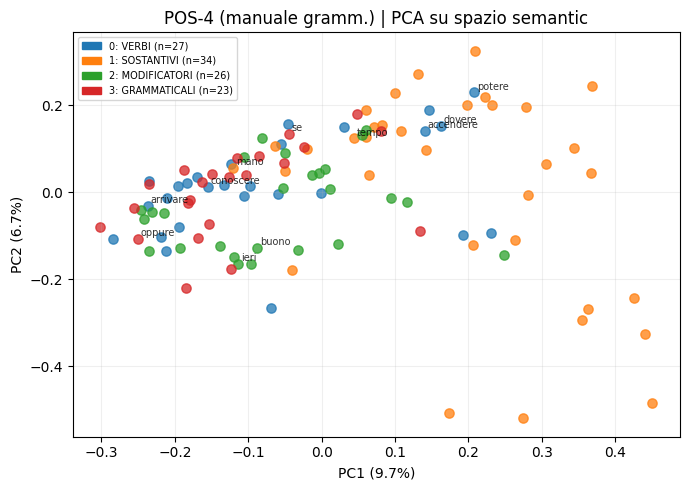

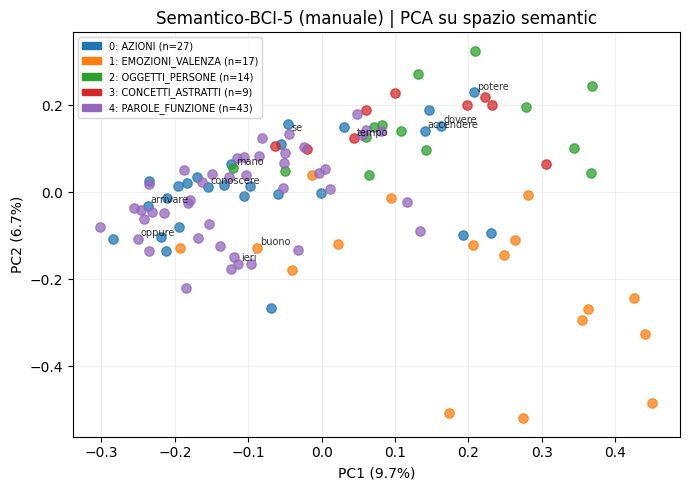

In [17]:
import matplotlib.patches as mpatches

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(emb)
var1, var2 = pca.explained_variance_ratio_

scheme_registry = [
    ("Ward-4 (automatico)", np.array([word2cluster_4[w] for w in true_labels]), ["C0","C1","C2","C3"], "semantic"),
    ("Ward-5 (automatico)", np.array([word2cluster_5[w] for w in true_labels]), ["C0","C1","C2","C3","C4"], "semantic"),
    ("POS-4 (manuale gramm.)", np.array([word2cluster_pos4[w] for w in true_labels]), cat_names_pos4, "semantic"),
    ("Semantico-BCI-5 (manuale)", np.array([word2cluster_sem5[w] for w in true_labels]), cat_names_sem5, "semantic"),
]

if word2cluster_psycho4 is not None:
    scheme_registry.append(("Psycho-4", np.array([word2cluster_psycho4[w] for w in true_labels]), ["C0","C1","C2","C3"], "psycho"))
if word2cluster_psycho5 is not None:
    scheme_registry.append(("Psycho-5", np.array([word2cluster_psycho5[w] for w in true_labels]), ["C0","C1","C2","C3","C4"], "psycho"))

cmap = plt.get_cmap("tab10")
annotate_idx = set(range(0, len(true_labels), ANNOTATE_EVERY))

for title, labels, cat_names, space_name in scheme_registry:
    plt.figure(figsize=(7, 5))
    patches = []
    for c in sorted(set(labels)):
        mask = labels == c
        color = cmap(c % 10)
        name = cat_names[c] if c < len(cat_names) else f"C{c}"
        plt.scatter(coords[mask, 0], coords[mask, 1], s=45, alpha=0.75, color=color)
        patches.append(mpatches.Patch(color=color, label=f"{c}: {name} (n={mask.sum()})"))

    for i, (w, x, y) in enumerate(zip(true_labels, coords[:, 0], coords[:, 1])):
        if i in annotate_idx:
            plt.annotate(w, (x, y), fontsize=7, alpha=0.8, xytext=(2, 2), textcoords="offset points")

    plt.title(f"{title} | PCA su spazio {space_name}")
    plt.xlabel(f"PC1 ({var1:.1%})")
    plt.ylabel(f"PC2 ({var2:.1%})")
    plt.legend(handles=patches, fontsize=7, framealpha=0.8)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
    plt.close()


In [18]:
comparison_rows = []

for title, labels, _, space_name in scheme_registry:
    arr = np.asarray(labels)
    row = {"schema": title, "k": int(len(np.unique(arr))), "space": space_name}

    if len(np.unique(arr)) > 1:
        row["silhouette_semantic"] = float(silhouette_score(emb, arr))
        row["db_semantic"]         = float(davies_bouldin_score(emb, arr))
    else:
        row["silhouette_semantic"] = np.nan
        row["db_semantic"]         = np.nan

    comparison_rows.append(row)

# Schemi EEG: silhouette nello spazio EEG (non confrontabile con gli altri)
for schema_name, eeg_map, eeg_labels in [
    ("EEG-4 (ward)", word2cluster_eeg4, eeg_labels_4 if word2cluster_eeg4 is not None else None),
    ("EEG-5 (kmeans)", word2cluster_eeg5, eeg_labels_5 if word2cluster_eeg5 is not None else None),
]:
    if eeg_map is not None and eeg_prototypes is not None and eeg_labels is not None:
        sil_eeg = float(silhouette_score(eeg_prototypes, eeg_labels))
        db_eeg  = float(davies_bouldin_score(eeg_prototypes, eeg_labels))
        # silhouette semantica (proiezione delle stesse parole sugli embedding SBERT)
        # NOTE: solo parole con prototipo EEG disponibile
        valid_arr = np.array([eeg_map[w] for w in true_labels if w in eeg_map])
        emb_valid = emb[[i for i, w in enumerate(true_labels) if w in eeg_map]]
        sil_sem = float(silhouette_score(emb_valid, valid_arr)) if len(np.unique(valid_arr)) > 1 else np.nan
        comparison_rows.append({
            "schema": schema_name,
            "k": int(len(np.unique(eeg_labels))),
            "space": "eeg",
            "silhouette_semantic": round(sil_sem, 4),
            "db_semantic":         np.nan,
            "silhouette_eeg":      round(sil_eeg, 4),
            "db_eeg":              round(db_eeg, 4),
        })
    else:
        comparison_rows.append({
            "schema": schema_name, "k": 4 if "4" in schema_name else 5,
            "space": "eeg",
            "silhouette_semantic": np.nan, "db_semantic": np.nan,
            "silhouette_eeg": np.nan,      "db_eeg": np.nan,
        })

df_compare = (
    pd.DataFrame(comparison_rows)
    .fillna(np.nan)
    .sort_values(["space", "k", "schema"])
    .reset_index(drop=True)
)

# Formatta per display
print("╔══ CONFRONTO SCHEMI DI CLUSTERING ══╗")
print("  silhouette_semantic: quanto i cluster sono coerenti nello spazio SBERT")
print("  silhouette_eeg:      quanto i cluster sono coerenti nello spazio delle feature EEG")
print("  n/a = metrica non applicabile per quello spazio\n")
display(df_compare[["schema", "k", "space", "silhouette_semantic", "db_semantic",
                     "silhouette_eeg", "db_eeg"]].round(4))

print("\n─── Raccomandazione ───")
print("1) Ward-4 / Ward-5   → baseline semantica automatica (oggettiva)")
print("2) POS-4             → baseline linguistica pura (interpretabile)")
print("3) Semantico-BCI-5   → schema neuroscientificamente motivato (raccomandato)")
print("4) EEG-4 / EEG-5     → cluster derivati dal segnale (rilevante per BCI)")
print("   ↳ La silhouette_eeg misura la struttura *nei dati cerebrali*, non nel linguaggio.")
print("   ↳ Per il training, la metrica finale che conta è la test accuracy nel decoder.")

print("\n─── File salvati ───")
for f in sorted(interim_dir.glob("*.json")):
    print(f"  {f.name}")


╔══ CONFRONTO SCHEMI DI CLUSTERING ══╗
  silhouette_semantic: quanto i cluster sono coerenti nello spazio SBERT
  silhouette_eeg:      quanto i cluster sono coerenti nello spazio delle feature EEG
  n/a = metrica non applicabile per quello spazio



,schema,k,space,silhouette_semantic,db_semantic,silhouette_eeg,db_eeg
0,EEG-4 (ward),4,eeg,-0.0294,NaN,0.0990,2.5955
1,EEG-5 (kmeans),5,eeg,-0.0435,NaN,0.0684,2.4983
2,POS-4 (manuale gramm.),4,semantic,-0.0330,4.3866,NaN,NaN
3,Ward-4 (automatico),4,semantic,0.0769,2.9770,NaN,NaN
4,Semantico-BCI-5 (manuale),5,semantic,-0.0080,4.1620,NaN,NaN
5,Ward-5 (automatico),5,semantic,0.0260,3.1023,NaN,NaN



─── Raccomandazione ───
1) Ward-4 / Ward-5   → baseline semantica automatica (oggettiva)
2) POS-4             → baseline linguistica pura (interpretabile)
3) Semantico-BCI-5   → schema neuroscientificamente motivato (raccomandato)
4) EEG-4 / EEG-5     → cluster derivati dal segnale (rilevante per BCI)
   ↳ La silhouette_eeg misura la struttura *nei dati cerebrali*, non nel linguaggio.
   ↳ Per il training, la metrica finale che conta è la test accuracy nel decoder.

─── File salvati ───
  cluster_names_eeg_4.json
  cluster_names_eeg_5.json
  cluster_names_pos4.json
  cluster_names_sem5.json
  idx2label.json
  label2idx.json
  labelid2cluster_4.json
  labelid2cluster_5.json
  labelid2cluster_eeg_4.json
  labelid2cluster_eeg_5.json
  labelid2cluster_pos4.json
  labelid2cluster_sem5.json
  word2cluster_4.json
  word2cluster_5.json
  word2cluster_eeg_4.json
  word2cluster_eeg_5.json
  word2cluster_fine.json
  word2cluster_pos4.json
  word2cluster_sem5.json
